# Mean Reversion Strategy

![Screenshot 2026-06-23 at 4.27.49 PM.png](<attachment:Screenshot 2026-06-23 at 4.27.49 PM.png>)
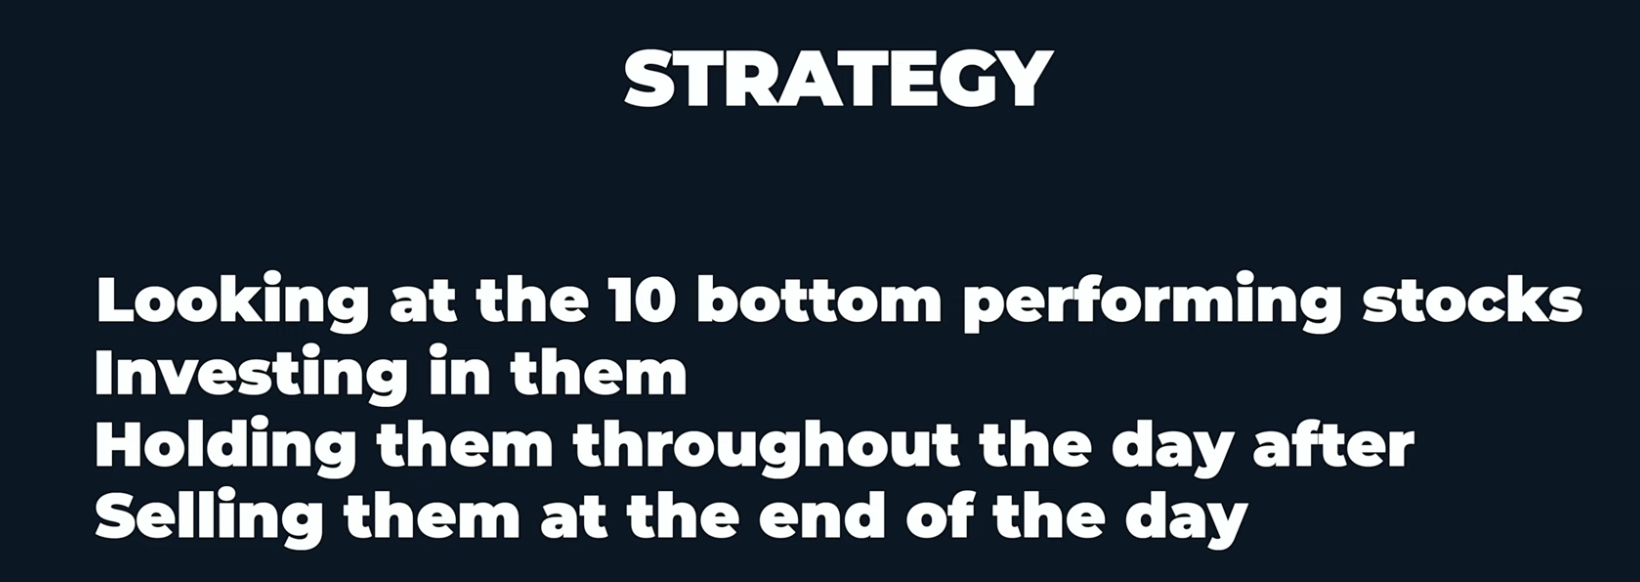

## Data Retrieval Process



![Screenshot 2026-06-23 at 4.22.07 PM.png](<attachment:Screenshot 2026-06-23 at 4.22.07 PM.png>)
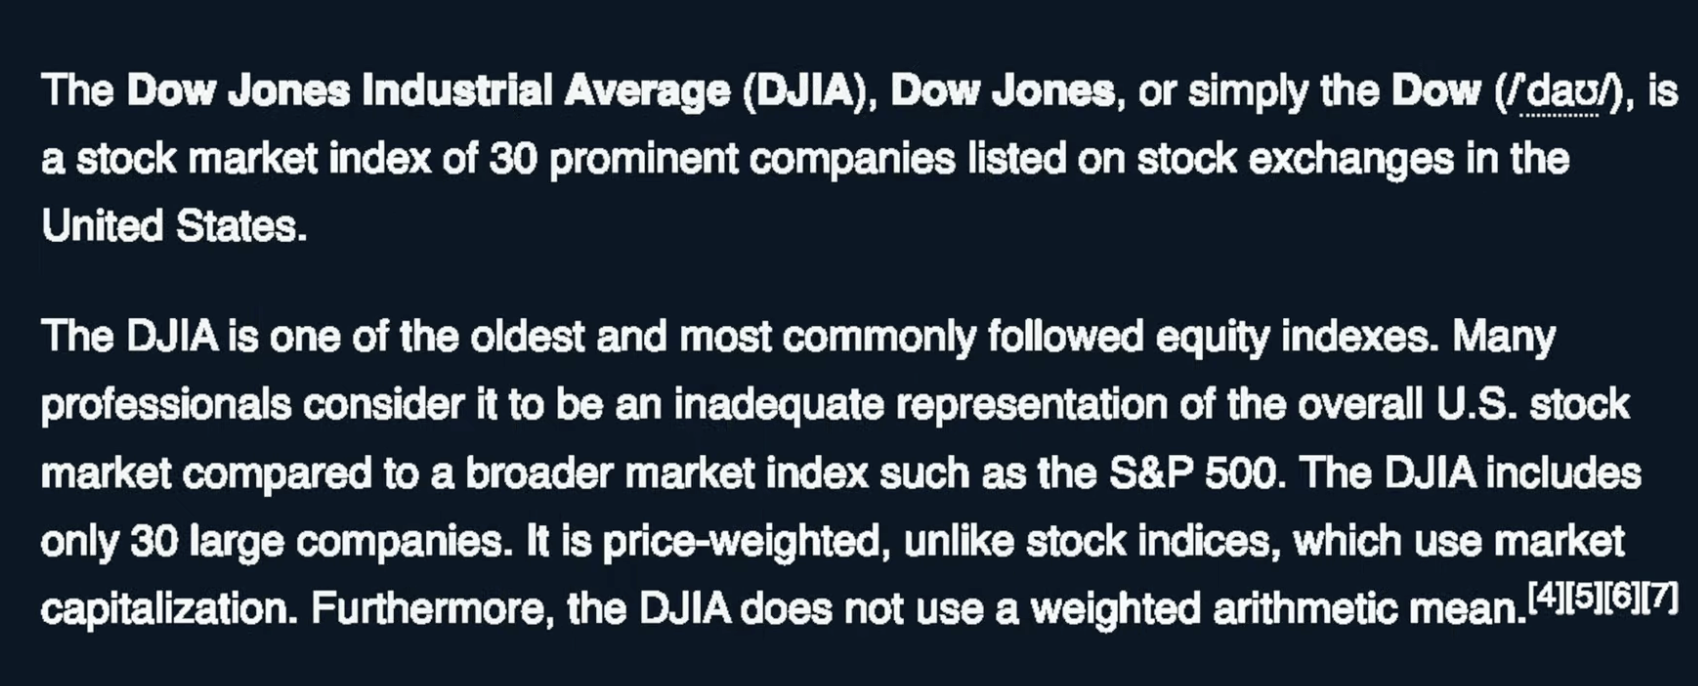

In [1]:
%pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta
from io import StringIO

In [3]:
import requests

url = "https://en.wikipedia.org/wiki/Dow_Jones_Industrial_Average"

response = requests.get(

    url,

    headers={"User-Agent": "Mozilla/5.0"} # Pretend to be a browser to avoid request blocking

)

print(response.status_code)

200


In [4]:
tables = pd.read_html(StringIO(response.text))

print(len(tables))

33


In [5]:
# each table contains some data in the form of datafame 
for i, table in enumerate(tables):

    print(f"\nTABLE {i}")

    print(table.head())


TABLE 0
                                                   0  \
0  Historical logarithmic graph of the DJIA from ...   
1                                         Foundation   
2                                           Operator   
3                                          Exchanges   
4                                     Trading symbol   

                                                   1  
0  Historical logarithmic graph of the DJIA from ...  
1  February 16, 1885; 141 years ago (as DJA)[1] M...  
2                              S&P Dow Jones Indices  
3                      New York Stock ExchangeNasdaq  
4                                  ^DJI$INDU.DJIDJIA  

TABLE 1
            Company Exchange Symbol                  Sector  Date added  \
0                3M     NYSE    MMM             Industrials  1976-08-09   
1  American Express     NYSE    AXP              Financials  1982-08-30   
2             Amgen   NASDAQ   AMGN             Health Care  2020-08-31   
3            Am

### this table from the wikipedia page tells us that which companies do we want in our stock data

In [6]:
# table[1] is the required data for backtesting 
tables[1].head()

,Company,Exchange,Symbol,Sector,Date added,Notes,Index weighting
0,3M,NYSE,MMM,Industrials,1976-08-09,As Minnesota Mining and Manufacturing,1.97%
1,American Express,NYSE,AXP,Financials,1982-08-30,NaN,3.98%
2,Amgen,NASDAQ,AMGN,Health Care,2020-08-31,NaN,4.70%
3,Amazon,NASDAQ,AMZN,Consumer Discretionary,2024-02-26,NaN,2.80%
4,Apple,NASDAQ,AAPL,Information Technology,2015-03-19,NaN,3.36%


In [7]:
dow_jones_constituents = tables[1] #storing table 1 data
dow_jones_constituents.to_csv('dow_jones_constituents.csv',index=False)#storing the dataframe into csv file


# Initialize an empty dataframe for storing stock data
stock_data = pd.DataFrame()

#getting the date of the day last 10 years from today 
start_date = datetime.now() - timedelta(days=365*10)

In [8]:
for symbol in dow_jones_constituents['Symbol']:
    try:
        ticker_data = yf.download(symbol, start=start_date) # eg- get apple stock data starting from 2016 to 2026(current time)
        ticker_data.columns = ticker_data.columns.get_level_values(0) # prevent multi index
        ticker_data['Symbol'] = symbol # creating a new column names "symbol" where the stock name will be there
        stock_data = pd.concat([stock_data, ticker_data]) # keep joining row wise , we'll finally get stock_data for all stock companies 
    except Exception as e:
        print(f"Error occurred for symbol: {symbol}, {str(e)}")

# Save the fetched data to CSV
stock_data.to_csv('dow_jones_data.csv')

# Load the data from CSV to pandas DataFrame
dj_constituents = pd.read_csv('dow_jones_constituents.csv')
dj_data = pd.read_csv('dow_jones_data.csv')

# Replace missing data using forward fill method
dj_constituents.fillna(method='ffill', inplace=True)
dj_data.fillna(method='ffill', inplace=True)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

In [9]:
stock_data.head()

Price,Close,High,Low,Open,Volume,Symbol
Date,,,,,,
2016-06-27,100.943947,101.330354,99.718296,101.300174,3042744,MMM
2016-06-28,102.392960,102.441265,101.408823,101.517498,2675811,MMM
2016-06-29,103.558266,103.757502,102.857888,103.256382,2265344,MMM
2016-06-30,105.731834,105.743911,103.884302,103.884302,2929482,MMM
2016-07-01,105.985413,106.311449,105.605044,105.743910,2309356,MMM


In [10]:
dj_data.head()

,Date,Close,High,Low,Open,Volume,Symbol
0,2016-06-27,100.943947,101.330354,99.718296,101.300174,3042744,MMM
1,2016-06-28,102.392960,102.441265,101.408823,101.517498,2675811,MMM
2,2016-06-29,103.558266,103.757502,102.857888,103.256382,2265344,MMM
3,2016-06-30,105.731834,105.743911,103.884302,103.884302,2929482,MMM
4,2016-07-01,105.985413,106.311449,105.605044,105.743910,2309356,MMM


In [11]:
ticker_data = yf.download("AAPL", start=start_date)

print(ticker_data.head())

print(ticker_data.columns)

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2016-06-27  20.952875  21.182802  20.829944  21.171419  181958400
2016-06-28  21.305731  21.321668  20.975640  21.148654  161779600
2016-06-29  21.490122  21.524270  21.314831  21.392232  146124000
2016-06-30  21.763306  21.802006  21.467362  21.499233  143345600
2016-07-01  21.829323  21.961360  21.701840  21.738263  104106000
MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])


## Implementing the Mean Reversion Strategy

### Step 1: Calculate Daily Returns


#### daily return:- (Today Close - Yesterday Close)/yesterday close



In [12]:
dj_data['Yesterday Close'] = (
     dj_data.groupby('Symbol')['Close'].shift(1)
)

dj_data['Daily Return'] = (
    (dj_data['Close'] - dj_data['Yesterday Close'])/ dj_data['Yesterday Close']
)

In [13]:
dj_data.head()

,Date,Close,High,Low,Open,Volume,Symbol,Yesterday Close,Daily Return
0,2016-06-27,100.943947,101.330354,99.718296,101.300174,3042744,MMM,NaN,NaN
1,2016-06-28,102.392960,102.441265,101.408823,101.517498,2675811,MMM,100.943947,0.014355
2,2016-06-29,103.558266,103.757502,102.857888,103.256382,2265344,MMM,102.392960,0.011381
3,2016-06-30,105.731834,105.743911,103.884302,103.884302,2929482,MMM,103.558266,0.020989
4,2016-07-01,105.985413,106.311449,105.605044,105.743910,2309356,MMM,105.731834,0.002398


## Step 2: Identify Biggest Losers



In [14]:
# remove first day rows/data
dj_data_without_first_day = dj_data[dj_data['Date'] != dj_data['Date'].min()]

# Group by 'Date' and apply a lambda function to sort and get 10 first items
lowest_daily_returns = dj_data_without_first_day.groupby('Date', as_index=False).apply(lambda x: x.nsmallest(10, 'Daily Return')).reset_index(drop=True)

# View the results
lowest_daily_returns.head(20)

/var/folders/z0/_htd4v5x41z7gjghsdxftct80000gn/T/ipykernel_2250/4112702367.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  lowest_daily_returns = dj_data_without_first_day.groupby('Date', as_index=False).apply(lambda x: x.nsmallest(10, 'Daily Return')).reset_index(drop=True)


,Date,Close,High,Low,Open,Volume,Symbol,Yesterday Close,Daily Return
0,2016-06-28,20.081011,20.182105,19.845128,20.151215,25683600,WMT,20.078201,0.000140
1,2016-06-28,32.228767,32.328712,31.946575,32.193492,17780600,VZ,32.181732,0.001462
2,2016-06-28,50.342190,50.959511,49.690089,50.646502,8294300,AXP,50.142200,0.003988
3,2016-06-28,39.024330,39.087521,38.694328,38.926033,13372585,MRK,38.834747,0.004882
4,2016-06-28,32.333115,32.340432,31.959870,32.245293,16509800,KO,32.040367,0.009137
5,2016-06-28,113.051567,113.845458,111.965671,113.608202,4438100,BA,111.965660,0.009699
6,2016-06-28,117.610840,117.933029,116.712065,117.186895,4160200,UNH,116.254265,0.011669
7,2016-06-28,66.538368,66.780613,65.890205,66.269939,7171100,CVX,65.706879,0.012655
8,2016-06-28,102.392960,102.441265,101.408823,101.517498,2675811,MMM,100.943947,0.014355
9,2016-06-28,89.926018,90.032502,88.648206,89.119775,10089600,JNJ,88.648201,0.014414


## Step 3: Simulate Trades



In [15]:
import pandas as pd
import numpy as np

In [16]:
#  Convert dates to actual datetime objects
lowest_daily_returns['Date'] = pd.to_datetime(lowest_daily_returns['Date'])
dj_data['Date'] = pd.to_datetime(dj_data['Date']) # originally these dates were in strings, but now pandas will actually see them as dates 

lowest_daily_returns = lowest_daily_returns.sort_values('Date')

dj_data = dj_data.sort_values('Date')

# Get unique dates
unique_dates = lowest_daily_returns['Date'].unique()

In [ ]:
next_date = unique_dates[1]

sell_price = dj_data[(dj_data['Date'] == next_date) & (dj_data['Symbol'] == symbol)]['Close'].values
print(sell_price) # sell price is an array like object, so to extract actual value we have to use sell_price[0]

[20.34777451]


### live trading

In [21]:
## Initialize capital and results DataFrame
initial_capital = 100000
results = pd.DataFrame(columns=['Date', 'Capital'])


for i, current_date in enumerate(unique_dates[:-1]):  # Exclude last date
     amount_per_stock = initial_capital/10
     next_date = unique_dates[i+1]

     # Select 10 worst performers for the current date
     current_day_losers = lowest_daily_returns[lowest_daily_returns['Date'] == current_date].nsmallest(10, 'Daily Return')
    
     if len(current_day_losers) < 10:
        continue  # Skip if we don't have 10 stocks
     total_value = 0
     for _, stock in current_day_losers.iterrows():
        symbol = stock['Symbol']

         # Find buy and sell prices
        buy_price = stock['Close']
        sell_price = dj_data[(dj_data['Date'] == next_date) & (dj_data['Symbol'] == symbol)]['Close'].values

        if len(sell_price) == 0 or np.isnan(buy_price) or np.isnan(sell_price[0]):
            continue  # Skip if we're missing price data

        # Calculate number of shares and value
        shares = amount_per_stock / buy_price
        value = shares * sell_price[0]
        total_value += value

     if total_value != 0:
      initial_capital = total_value
     
     # Store results
     results.loc[len(results)] = [next_date, initial_capital]

# Calculate and print results
final_capital = results['Capital'].iloc[-1] # Give me the last value in the Capital column.
total_return = (final_capital - 100000) / 100000 * 100

print(f"Final Capital: ${final_capital:.2f}")
print(f"Total Return: {total_return:.2f}%")

Final Capital: $485292.66
Total Return: 385.29%


## Step 4: Calculate Performance Metrics



In [26]:
# Calculation of Performance Metrics

# Assuming 252 trading days in a year
trading_days = 252

# Compute daily capital returns
results['Capital Return'] = results['Capital'].pct_change() 

# Annualized return
annual_return = (1 + results['Capital Return'].mean())**trading_days - 1

# Annualized volatility
annual_volatility = results['Capital Return'].std() * (trading_days**0.5)

# Sharpe Ratio assuming risk-free rate = 0
sharpe_ratio = annual_return / annual_volatility

results['Cumulative Return'] = (
    1 + results['Capital Return']
).cumprod()

results['Portfolio Value'] = (
    results['Cumulative Return']
    * 100000
)

# Printing the calculated metrics
print(f"Annualized Return : {annual_return*100:.2f}% ")
print(f"Annualized Volatility : {annual_volatility*100:.2f}% ")
print(f"Sharpe Ratio : {sharpe_ratio:.2f} ")

Annualized Return : 19.41% 
Annualized Volatility : 20.20% 
Sharpe Ratio : 0.96 


## Step 5: Compare with Dow Jones Index



In [27]:
import numpy as np

# Fetch the DIA ETF data from Yahoo Finance
dia_data = yf.download('DIA', start=start_date)

# Calculate the daily returns for DIA
dia_data['Daily Return'] = dia_data['Close'].pct_change()

# Calculate the Sharpe ratio for DIA
annual_return_dia = (1 + dia_data['Daily Return'].mean())**trading_days - 1
annual_volatility_dia = dia_data['Daily Return'].std() * np.sqrt(trading_days)
sharpe_ratio_dia = annual_return_dia / annual_volatility_dia

print(f"Sharpe Ratio for DIA: {sharpe_ratio_dia:.2f} ")

dia_data['Cumulative Return'] = (
    1 + dia_data['Daily Return']
).cumprod()

dia_data['Portfolio Value'] = (
    dia_data['Cumulative Return']
    * 100000
)
# Compare Sharpe ratios
if sharpe_ratio > sharpe_ratio_dia:
    print("Our mean reversion strategy outperformed the general Dow Jones.")
else:
    print("Our mean reversion strategy did not outperform the general Dow Jones.")

[*********************100%***********************]  1 of 1 completed

Sharpe Ratio for DIA: 0.90 
Our mean reversion strategy outperformed the general Dow Jones.


## Step 6: Compare Our Mean Reversion Strategies' Performance to that of the Dow Jones ETF



In [28]:
# Gathering calculated data for mean reversion strategy and DIA
data = {
    'Mean Reversion Strategy': [annual_return, annual_volatility, sharpe_ratio],
    'DIA': [annual_return_dia, annual_volatility_dia, sharpe_ratio_dia]
}

# Creating a pandas DataFrame with this data
df = pd.DataFrame(data, index=['Annual Return', 'Annual Std Dev', 'Sharpe Ratio'])

# Printing the DataFrame
print(df)

                Mean Reversion Strategy       DIA
Annual Return                  0.194136  0.157952
Annual Std Dev                 0.201952  0.175307
Sharpe Ratio                   0.961299  0.900997


## Step 7: Visualize Portfolio Growth



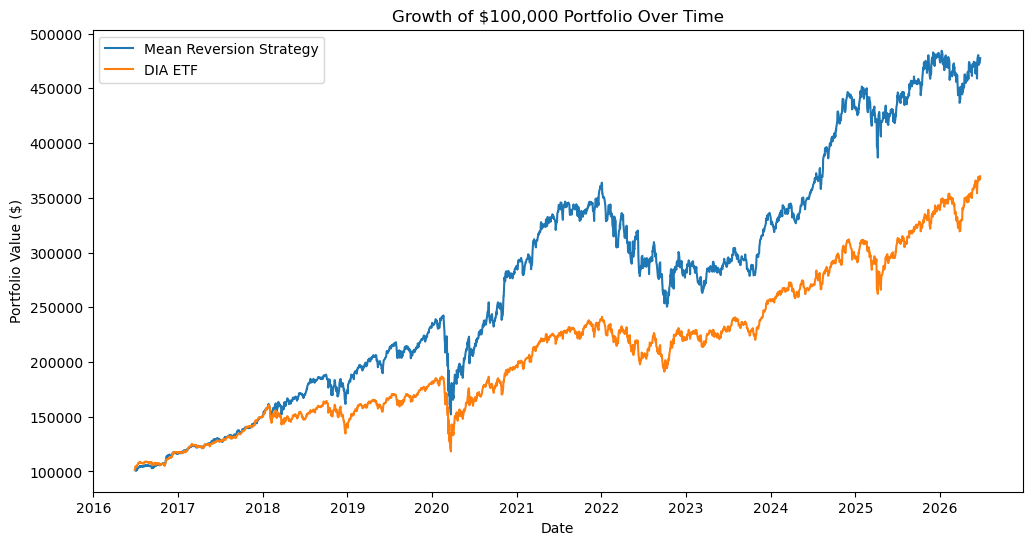

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    results['Date'],
    results['Portfolio Value'],
    label='Mean Reversion Strategy'
)

plt.plot(
    dia_data.index,
    dia_data['Portfolio Value'],
    label='DIA ETF'
)

plt.title('Growth of $100,000 Portfolio Over Time')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')

plt.legend()

plt.show()